In [1]:
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error, median_absolute_error
import pickle

df = pd.read_csv('./AirQuality_Cleaned.csv')
df['ds'] = pd.to_datetime(df['Date'], format='%Y-%m-%d')

results = {}
pollutants = ['PM2.5', 'PM10', 'O3', 'CO', 'SO2', 'NO2']

for pollutant in pollutants:
    print(f"Training Prophet model for {pollutant}...")
    data = df[['ds', pollutant]].rename(columns={pollutant: 'y'}).dropna()
    train = data.iloc[:-100]
    test = data.iloc[-100:]
    model = Prophet()
    model.fit(train)
    with open(f'{pollutant}_prophet_model.pkl', 'wb') as file:
        pickle.dump(model, file)
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)
    forecast_test = forecast.iloc[-100:]['yhat'].values
    test_actual = test['y'].values
    mae = mean_absolute_error(test_actual, forecast_test)
    mse = mean_squared_error(test_actual, forecast_test)
    mdape = median_absolute_error(test_actual, forecast_test) / test_actual.mean() * 100
    accuracy = max(0, 100 - mdape)
    results[pollutant] = {'MAE': mae, 'MSE': mse, 'MdAPE': mdape, 'Accuracy': accuracy}

for pollutant, metrics in results.items():
    print(f"{pollutant}: {metrics}")

C:\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


Training Prophet model for PM2.5...


19:09:02 - cmdstanpy - INFO - Chain [1] start processing
19:09:16 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model for PM10...


19:09:19 - cmdstanpy - INFO - Chain [1] start processing
19:09:34 - cmdstanpy - INFO - Chain [1] done processing


...

Training Prophet model for SO2...


19:10:03 - cmdstanpy - INFO - Chain [1] start processing
19:10:14 - cmdstanpy - INFO - Chain [1] done processing


Training Prophet model for NO2...


19:10:18 - cmdstanpy - INFO - Chain [1] start processing
19:10:28 - cmdstanpy - INFO - Chain [1] done processing


PM2.5: {'MAE': 12.587145095230163, 'MSE': 258.01912000491166, 'MdAPE': 52.35486709890751, 'Accuracy': 47.64513290109249}
PM10: {'MAE': 33.803769906624495, 'MSE': 1886.545247408626, 'MdAPE': 43.69691244840492, 'Accuracy': 56.30308755159508}
O3: {'MAE': 7.820164480724834, 'MSE': 95.94198167353363, 'MdAPE': 31.55040213459248, 'Accuracy': 68.44959786540753}
CO: {'MAE': 0.9692955027983458, 'MSE': 1.075374979583512, 'MdAPE': 320.0530110294024, 'Accuracy': 0}
SO2: {'MAE': 2.0921731141557305, 'MSE': 8.551795425853278, 'MdAPE': 17.03795236970896, 'Accuracy': 82.96204763029104}
NO2: {'MAE': 18.688411559235465, 'MSE': 447.8640996071689, 'MdAPE': 56.28217148445308, 'Accuracy': 43.71782851554692}


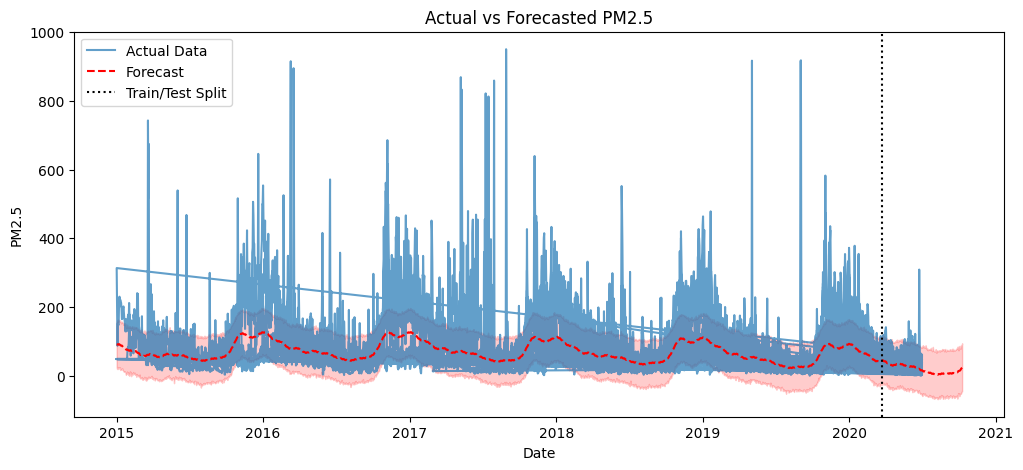

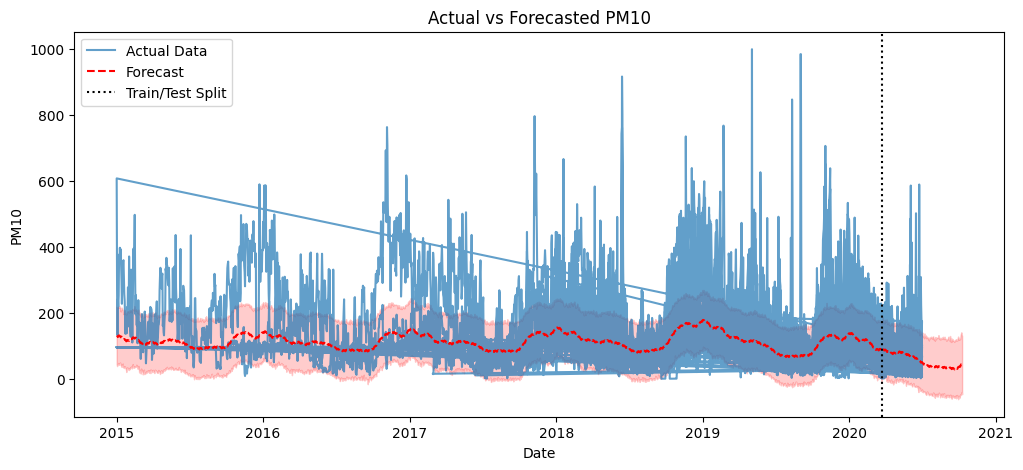

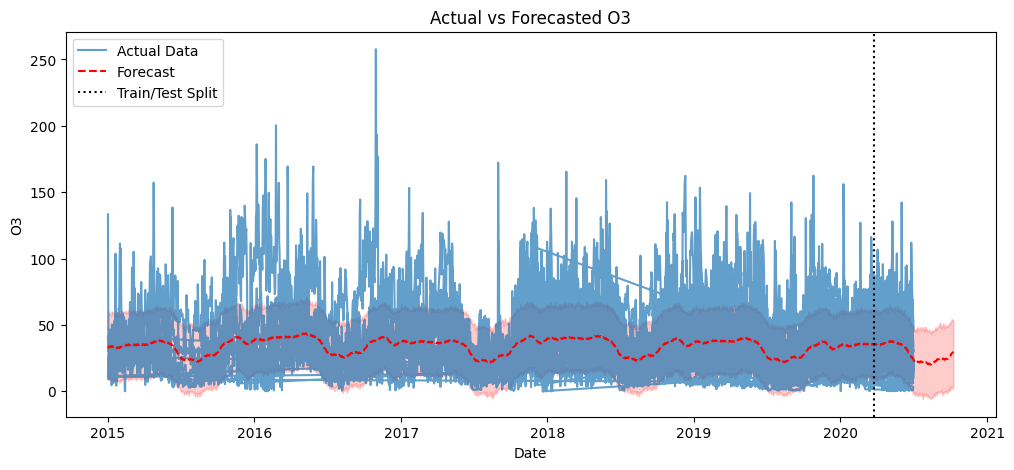

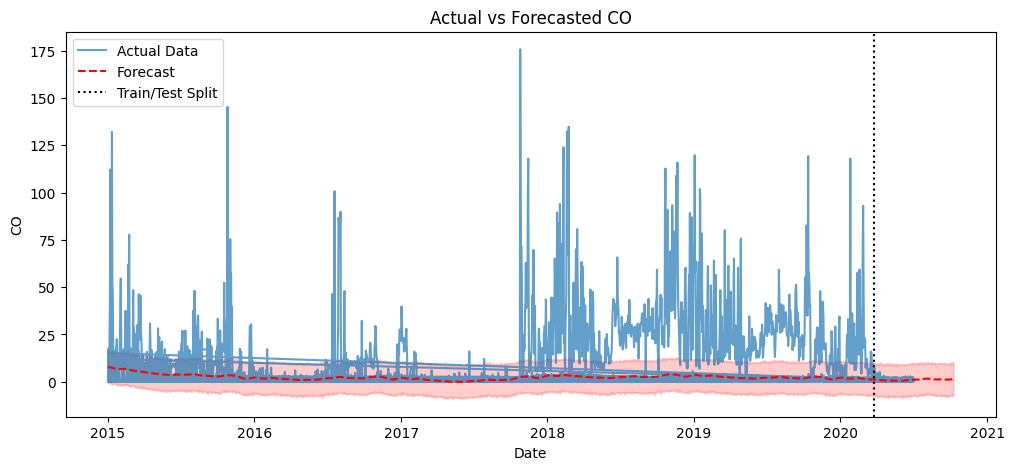

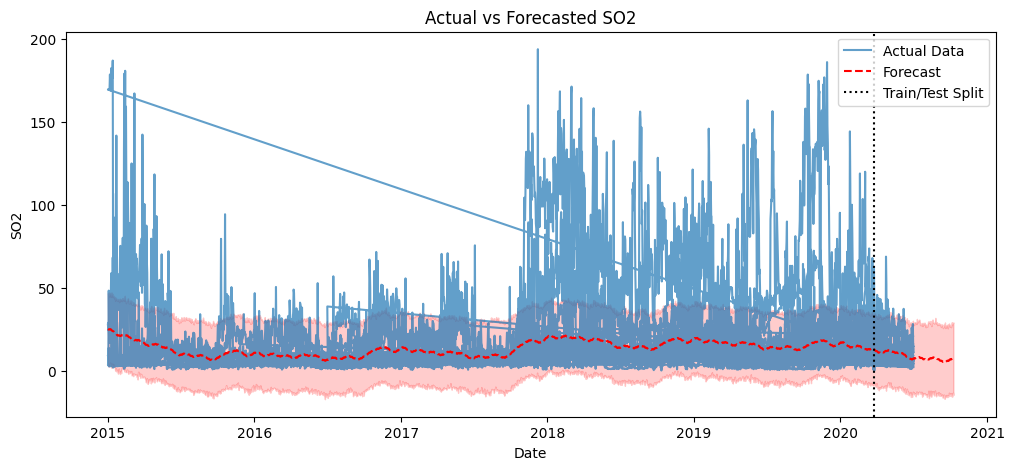

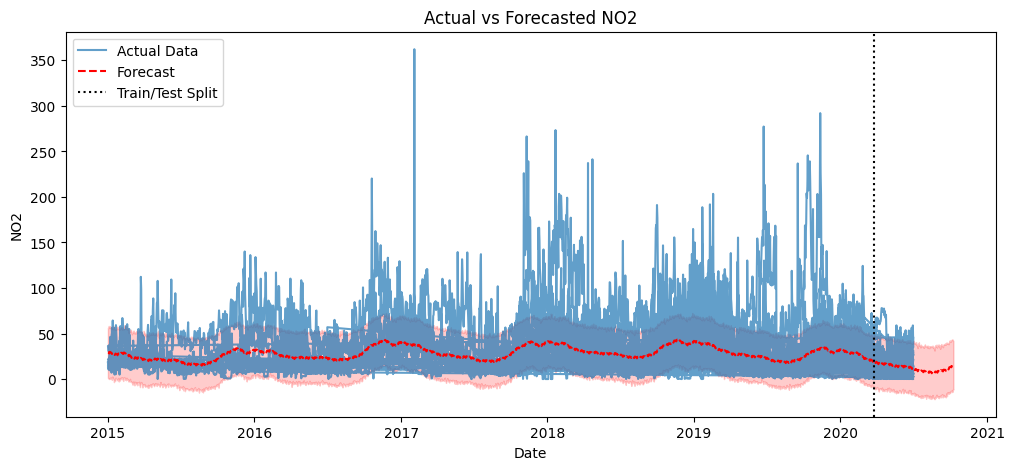

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\3931421863.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\3931421863.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\3931421863.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=

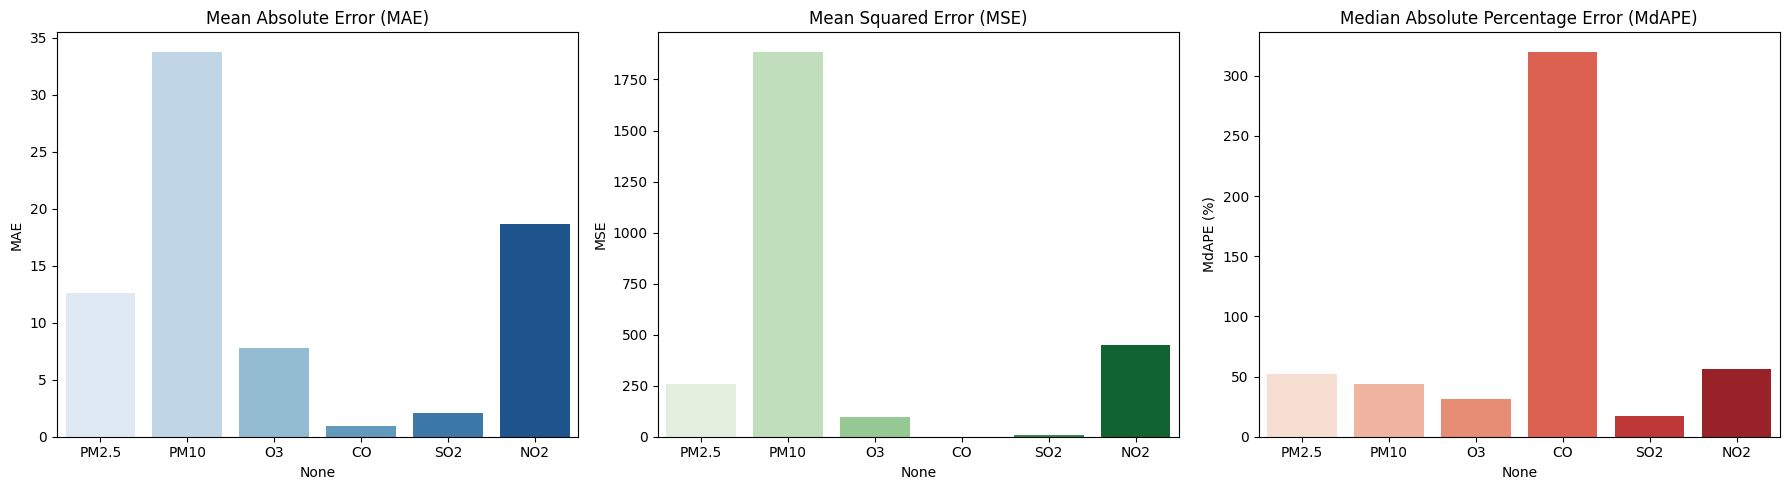

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\3931421863.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")


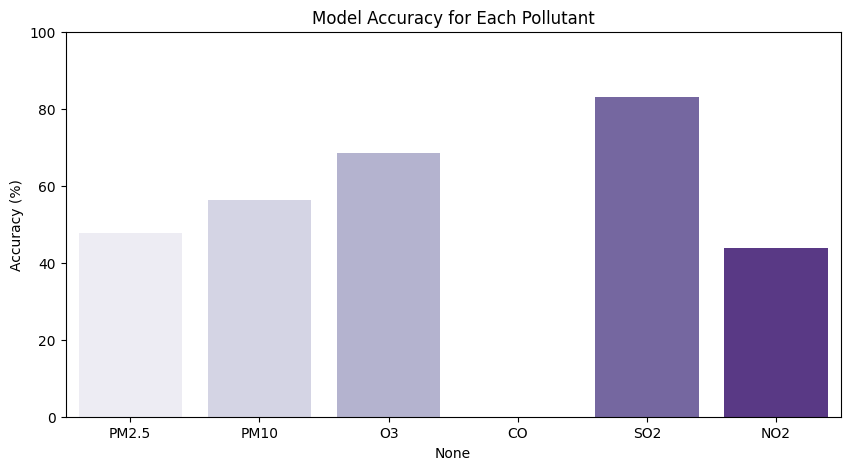

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot actual vs predicted values for each pollutant
for pollutant in pollutants:
    # Load the model
    with open(f'{pollutant}_prophet_model.pkl', 'rb') as file:
        model = pickle.load(file)
    
    # Make future dataframe and predict
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)
    
    # Plot
    plt.figure(figsize=(12, 5))
    plt.plot(df['ds'], df[pollutant], label="Actual Data", alpha=0.7)
    plt.plot(forecast['ds'], forecast['yhat'], label="Forecast", linestyle='dashed', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
    plt.axvline(df['ds'].iloc[-100], color='black', linestyle='dotted', label="Train/Test Split")
    plt.title(f'Actual vs Forecasted {pollutant}')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.legend()
    plt.show()

# Convert results dictionary to DataFrame for plotting error metrics
results_df = pd.DataFrame(results).T

# Plot error metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE")

# MSE
sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
axes[1].set_title("Mean Squared Error (MSE)")
axes[1].set_ylabel("MSE")

# MdAPE
sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=axes[2], palette="Reds")
axes[2].set_title("Median Absolute Percentage Error (MdAPE)")
axes[2].set_ylabel("MdAPE (%)")

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")
plt.title("Model Accuracy for Each Pollutant")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()


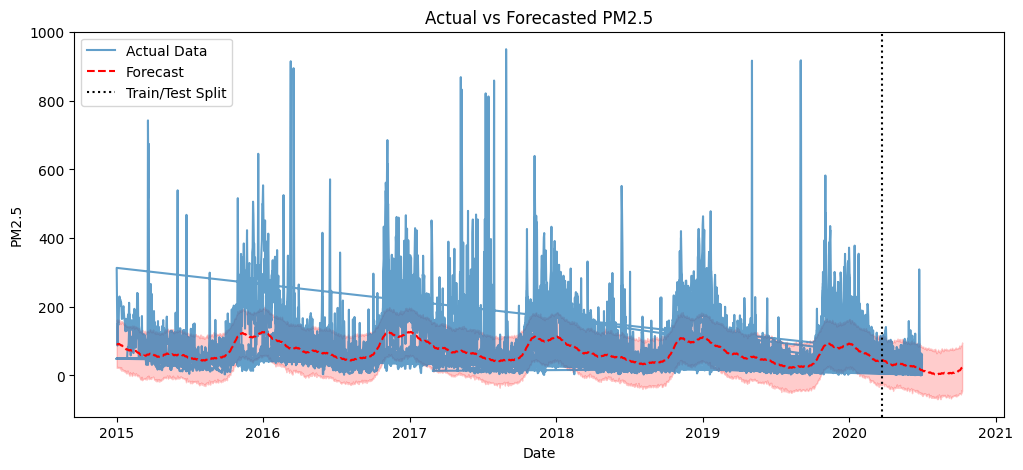

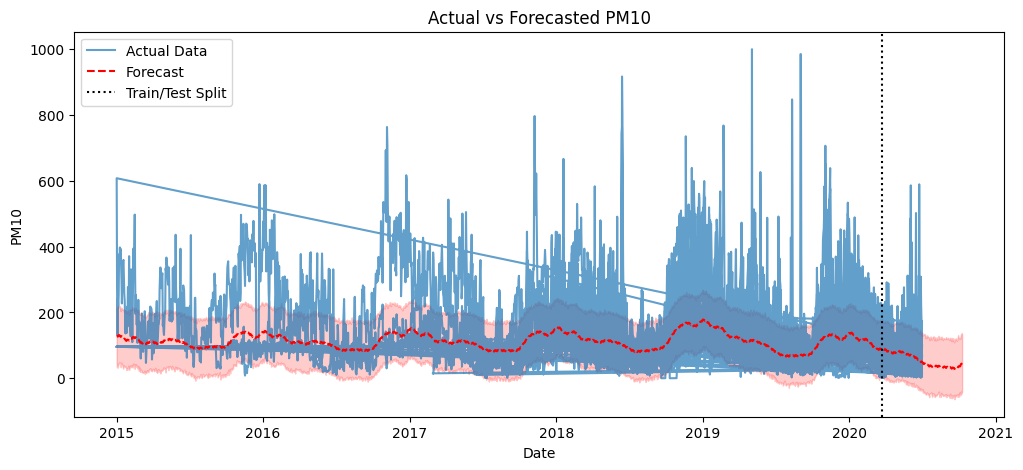

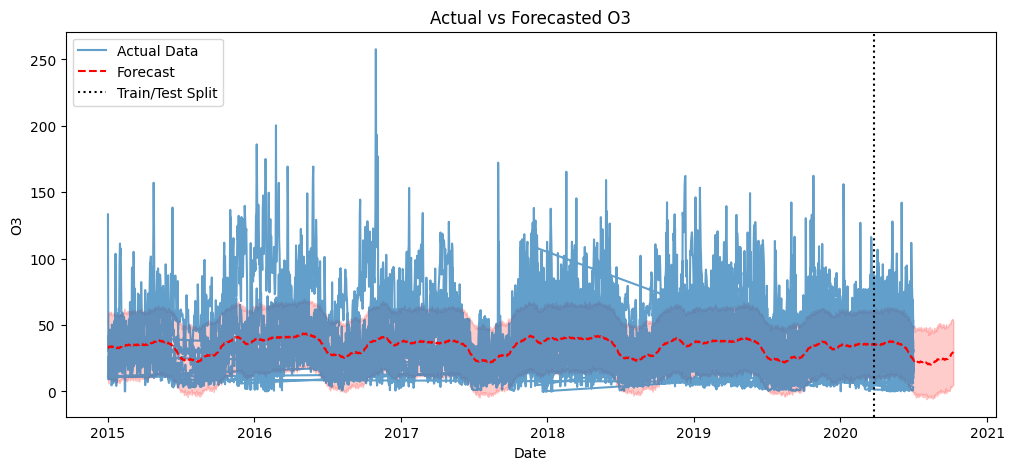

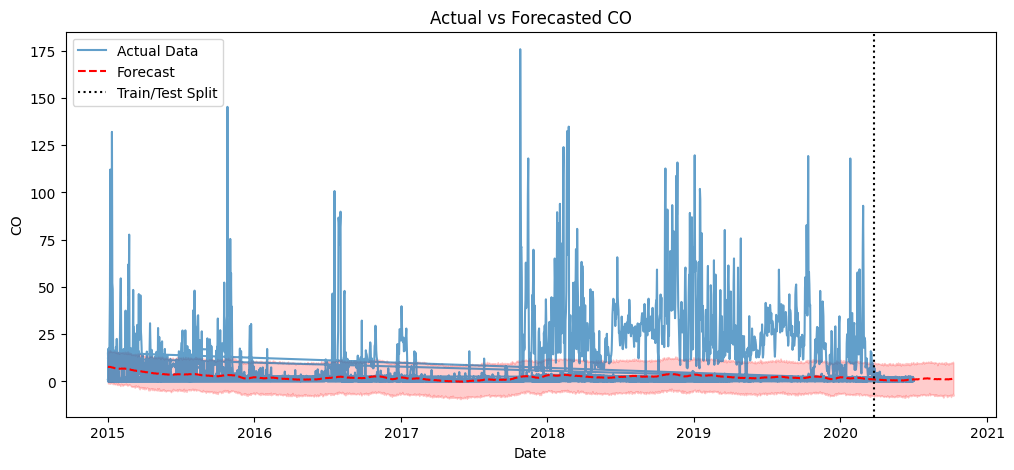

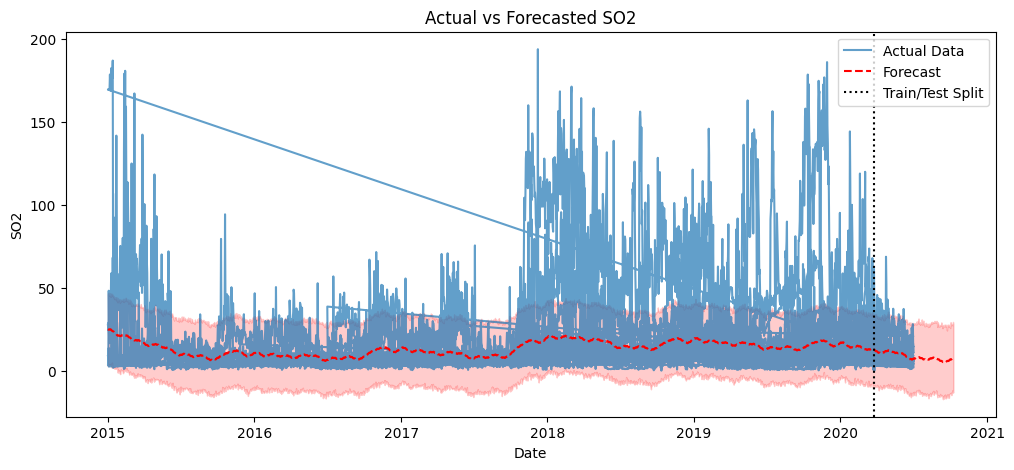

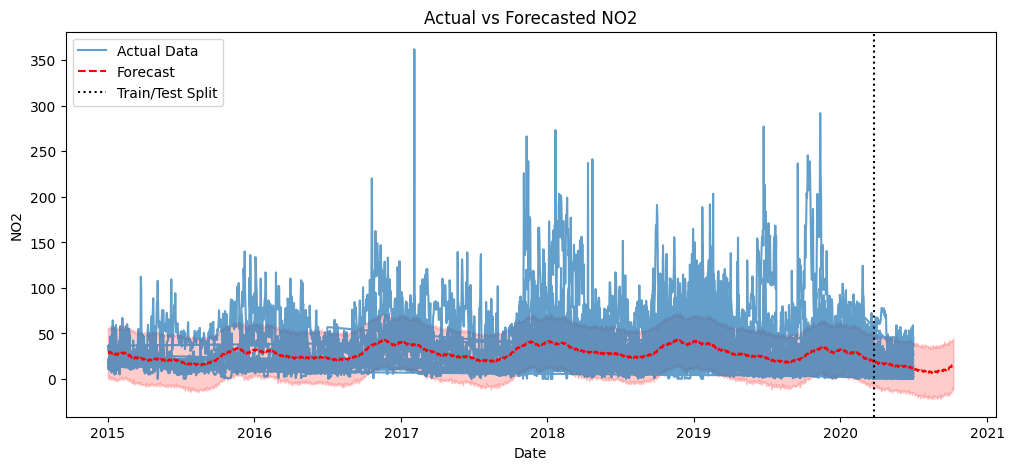

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\1725150706.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\1725150706.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\1725150706.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=

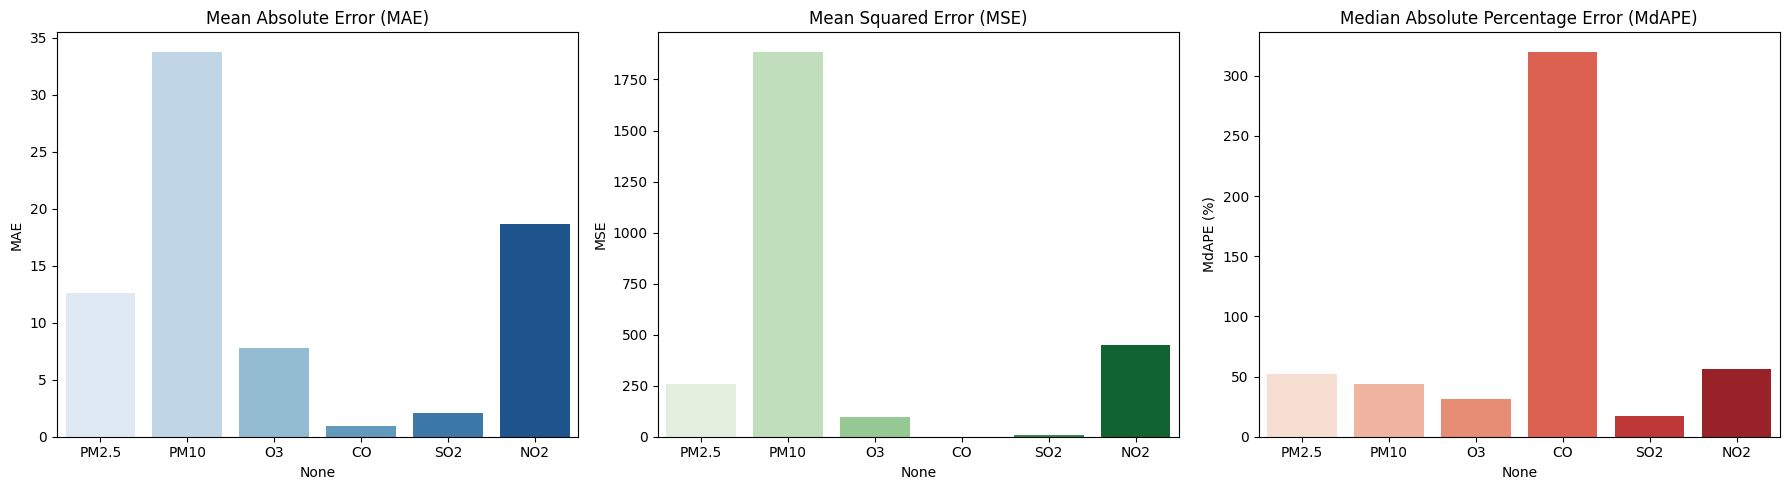

C:\Users\Ashita Singh\AppData\Local\Temp\ipykernel_8048\1725150706.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")


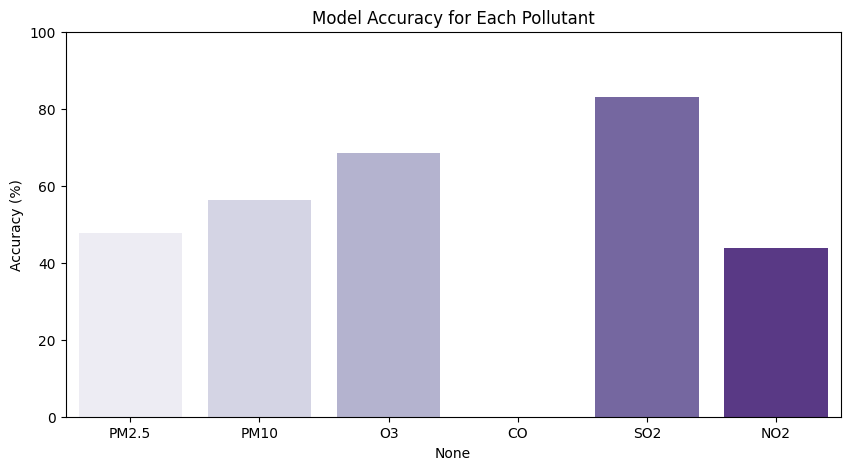

In [3]:
import matplotlib.pyplot as plt 
import seaborn as sns

# Plot actual vs predicted values for each pollutant
for pollutant in pollutants:
    # Load the model
    with open(f'{pollutant}_prophet_model.pkl', 'rb') as file:
        model = pickle.load(file)
    
    # Make future dataframe and predict
    future = model.make_future_dataframe(periods=100)
    forecast = model.predict(future)
    
    # Plot
    
    plt.figure(figsize=(12, 5))
    plt.plot(df['ds'], df[pollutant], label="Actual Data", alpha=0.7)
    plt.plot(forecast['ds'], forecast['yhat'], label="Forecast", linestyle='dashed', color='red')
    plt.fill_between(forecast['ds'], forecast['yhat_lower'], forecast['yhat_upper'], color='red', alpha=0.2)
    plt.axvline(df['ds'].iloc[-100], color='black', linestyle='dotted', label="Train/Test Split")
    plt.title(f'Actual vs Forecasted {pollutant}')
    plt.xlabel('Date')
    plt.ylabel(pollutant)
    plt.legend()
    plt.show()

# Convert results dictionary to DataFrame for plotting error metrics
results_df = pd.DataFrame(results).T

# Plot error metrics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
sns.barplot(x=results_df.index, y=results_df['MAE'], ax=axes[0], palette="Blues")
axes[0].set_title("Mean Absolute Error (MAE)")
axes[0].set_ylabel("MAE")

# MSE
sns.barplot(x=results_df.index, y=results_df['MSE'], ax=axes[1], palette="Greens")
axes[1].set_title("Mean Squared Error (MSE)")
axes[1].set_ylabel("MSE")

# MdAPE
sns.barplot(x=results_df.index, y=results_df['MdAPE'], ax=axes[2], palette="Reds")
axes[2].set_title("Median Absolute Percentage Error (MdAPE)")
axes[2].set_ylabel("MdAPE (%)")

plt.tight_layout()
plt.show()

# Plot accuracy comparison
plt.figure(figsize=(10, 5))
sns.barplot(x=results_df.index, y=results_df['Accuracy'], palette="Purples")
plt.title("Model Accuracy for Each Pollutant")
plt.ylabel("Accuracy (%)")
plt.ylim(0, 100)
plt.show()